In [91]:
#%pip install openbb-cboe openbb-derivatives

In [92]:
#%pip install -r req.txt

In [93]:
#%pip install nbformat

In [94]:
import datetime as dt
import pandas as pd
from openbb import obb
import numpy as np


In [95]:
tickerlbl = "GOOGL"

In [96]:

obb.user.preferences.output_type = "dataframe"
data = obb.equity.price.historical(tickerlbl, provider="yfinance")

In [97]:
display(data)

,open,high,low,close,volume,dividend
date,,,,,,
2025-03-05,170.520004,173.779999,169.059998,173.020004,30954900,0.0
2025-03-06,170.529999,174.809998,170.500000,172.350006,28302000,0.0
2025-03-07,171.259995,174.970001,170.270004,173.860001,27385800,0.0
2025-03-10,168.259995,168.460007,163.690002,165.869995,43604000,0.2
2025-03-11,164.910004,166.750000,161.369995,164.039993,39587400,0.0
...,...,...,...,...,...,...
2026-02-27,304.140015,312.369995,303.799988,311.760010,44640600,0.0
2026-03-02,303.230011,308.489990,301.299988,306.519989,34790200,0.0
2026-03-03,298.589996,303.940002,296.709991,303.579987,35497000,0.0


In [98]:
obb.equity.fundamental.metrics(
    tickerlbl,
    provider="yfinance"
)


,symbol,currency,market_cap,pe_ratio,forward_pe,peg_ratio_ttm,enterprise_to_ebitda,earnings_growth,earnings_growth_quarterly,revenue_per_share,...,book_value,price_to_book,enterprise_value,overall_risk,audit_risk,board_risk,compensation_risk,shareholder_rights_risk,beta,price_return_1y
0,GOOGL,USD,3631519629312,27.744919,22.380789,2.2857,24.019,0.311,0.298,33.248,...,34.353,8.738684,3607116644352,10.0,7.0,9.0,10.0,10.0,1.112,0.758805


In [99]:
calendar_dates = pd.date_range(
    start=data.index.min(),
    end=data.index.max(),
    freq="D"
)

calendar_dates

DatetimeIndex(['2025-03-05', '2025-03-06', '2025-03-07', '2025-03-08',
               '2025-03-09', '2025-03-10', '2025-03-11', '2025-03-12',
               '2025-03-13', '2025-03-14',
               ...
               '2026-02-24', '2026-02-25', '2026-02-26', '2026-02-27',
               '2026-02-28', '2026-03-01', '2026-03-02', '2026-03-03',
               '2026-03-04', '2026-03-05'],
              dtype='datetime64[ns]', length=366, freq='D')

In [100]:
try:
    result = obb.equity.compare.peers(
        group="technology",
        metric="performance",
        provider="finviz"
    )
    display(result)  # Display the result if the call is successful
except AttributeError as e:
    print(f"Error: {e}.  The 'peers' method may not exist or the arguments are incorrect. Please consult the OpenBB documentation for the correct usage.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")


An unexpected error occurred: 
[Error] -> 2 validations error(s)
[Arg] symbol -> input: ... -> Missing required argument
[Arg] provider -> input: finviz -> Input should be 'fmp'


In [101]:
from openbb import obb
# Esto te mostrará qué proveedores "entiende" tu máquina ahora mismo
print(obb.coverage.providers.get("derivatives.options.chains"))

None


In [102]:
chains = obb.derivatives.options.chains(
    tickerlbl,
    provider="cboe"
)
display(chains)

,underlying_symbol,underlying_price,contract_symbol,expiration,dte,strike,option_type,open_interest,volume,theoretical_price,...,low,prev_close,change,change_percent,implied_volatility,delta,gamma,theta,vega,rho
0,GOOGL,300.045,GOOGL260306C00100000,2026-03-06,1,100.0,call,4,0,200.1946,...,0.00,202.799995,0.000,0.000000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0055
1,GOOGL,300.045,GOOGL260306P00100000,2026-03-06,1,100.0,put,0,0,0.0000,...,0.00,0.005000,0.000,0.000000,5.7127,0.0000,0.0000,0.0000,0.0000,0.0000
2,GOOGL,300.045,GOOGL260306C00105000,2026-03-06,1,105.0,call,0,0,195.1957,...,0.00,197.799995,0.000,0.000000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0058
3,GOOGL,300.045,GOOGL260306P00105000,2026-03-06,1,105.0,put,0,0,0.0000,...,0.00,0.005000,0.000,0.000000,5.4668,0.0000,0.0000,0.0000,0.0000,0.0000
4,GOOGL,300.045,GOOGL260306C00110000,2026-03-06,1,110.0,call,0,0,190.1969,...,0.00,192.799995,0.000,0.000000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0060
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4403,GOOGL,300.045,GOOGL281215P00620000,2028-12-15,1016,620.0,put,0,0,319.8396,...,0.00,317.000000,0.000,0.000000,0.3954,-0.9762,0.0014,-0.0206,0.0000,0.0000
4404,GOOGL,300.045,GOOGL281215C00630000,2028-12-15,1016,630.0,call,287,0,20.2492,...,0.00,20.325001,0.000,0.000000,0.3748,0.2470,0.0017,-0.0266,1.5815,1.4709
4405,GOOGL,300.045,GOOGL281215P00630000,2028-12-15,1016,630.0,put,0,0,329.8396,...,0.00,327.000000,0.000,0.000000,0.4023,-0.9828,0.0010,-0.0206,0.0000,0.0000
4406,GOOGL,300.045,GOOGL281215C00640000,2028-12-15,1016,640.0,call,967,5,19.5242,...,19.11,19.625000,-0.425,-0.021656,0.3752,0.2398,0.0017,-0.0263,1.5570,1.4312


In [103]:
close = data["close"]
returns = close.pct_change()

std_dev = returns.dropna().std()
annualized_std_dev = std_dev * np.sqrt(252)

returns[np.isnan(returns)] = 0
returns += 1
log_returns = np.log(close / close.shift())



<Axes: xlabel='date'>

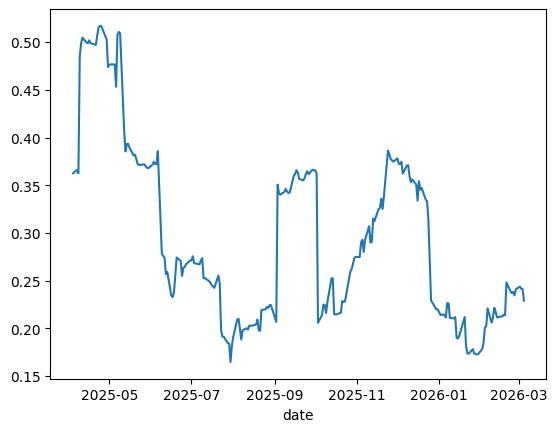

In [104]:
(
    close
    .pct_change()
    .rolling(window=22)
    .std()
    * np.sqrt(252)
).plot()

<Axes: title={'center': 'RKLB returns'}, xlabel='date'>

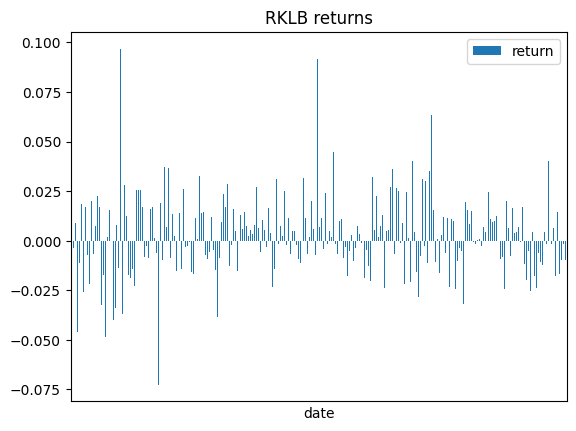

In [105]:
returns = data.close.pct_change()
returns.name = "return"
returns.plot.bar(
    title="RKLB returns",
    grid=False,
    legend=True,
    xticks=[]
)

<Axes: xlabel='date'>

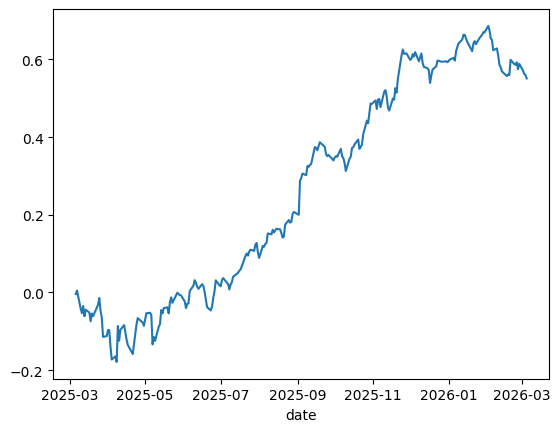

In [106]:

log_returns = np.log(close / close.shift())
cumulative_log_returns = log_returns.cumsum()
cumulative_log_returns.plot()


<Axes: ylabel='Frequency'>

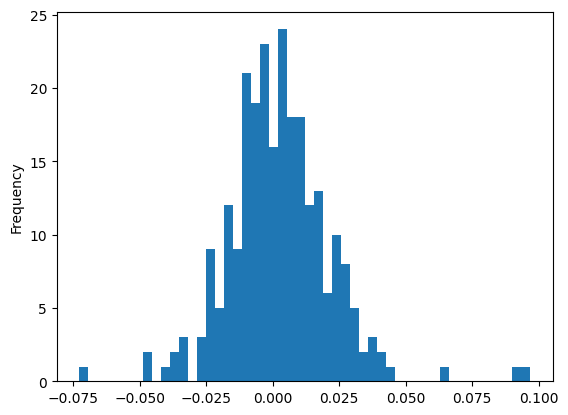

In [107]:
returns.plot.hist(bins=50)


In [108]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
from openbb import obb
obb.user.preferences.output_type = "dataframe"


In [109]:
chains = obb.derivatives.options.chains(
    tickerlbl,
    provider="cboe"
)
chains

,underlying_symbol,underlying_price,contract_symbol,expiration,dte,strike,option_type,open_interest,volume,theoretical_price,...,low,prev_close,change,change_percent,implied_volatility,delta,gamma,theta,vega,rho
0,GOOGL,300.045,GOOGL260306C00100000,2026-03-06,1,100.0,call,4,0,200.1946,...,0.00,202.799995,0.000,0.000000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0055
1,GOOGL,300.045,GOOGL260306P00100000,2026-03-06,1,100.0,put,0,0,0.0000,...,0.00,0.005000,0.000,0.000000,5.7127,0.0000,0.0000,0.0000,0.0000,0.0000
2,GOOGL,300.045,GOOGL260306C00105000,2026-03-06,1,105.0,call,0,0,195.1957,...,0.00,197.799995,0.000,0.000000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0058
3,GOOGL,300.045,GOOGL260306P00105000,2026-03-06,1,105.0,put,0,0,0.0000,...,0.00,0.005000,0.000,0.000000,5.4668,0.0000,0.0000,0.0000,0.0000,0.0000
4,GOOGL,300.045,GOOGL260306C00110000,2026-03-06,1,110.0,call,0,0,190.1969,...,0.00,192.799995,0.000,0.000000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0060
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4403,GOOGL,300.045,GOOGL281215P00620000,2028-12-15,1016,620.0,put,0,0,319.8396,...,0.00,317.000000,0.000,0.000000,0.3954,-0.9762,0.0014,-0.0206,0.0000,0.0000
4404,GOOGL,300.045,GOOGL281215C00630000,2028-12-15,1016,630.0,call,287,0,20.2492,...,0.00,20.325001,0.000,0.000000,0.3748,0.2470,0.0017,-0.0266,1.5815,1.4709
4405,GOOGL,300.045,GOOGL281215P00630000,2028-12-15,1016,630.0,put,0,0,329.8396,...,0.00,327.000000,0.000,0.000000,0.4023,-0.9828,0.0010,-0.0206,0.0000,0.0000
4406,GOOGL,300.045,GOOGL281215C00640000,2028-12-15,1016,640.0,call,967,5,19.5242,...,19.11,19.625000,-0.425,-0.021656,0.3752,0.2398,0.0017,-0.0263,1.5570,1.4312


In [110]:
expirations = chains.expiration.unique()
expirations

array([datetime.date(2026, 3, 6), datetime.date(2026, 3, 9),
       datetime.date(2026, 3, 11), datetime.date(2026, 3, 13),
       datetime.date(2026, 3, 16), datetime.date(2026, 3, 18),
       datetime.date(2026, 3, 20), datetime.date(2026, 3, 27),
       datetime.date(2026, 4, 2), datetime.date(2026, 4, 10),
       datetime.date(2026, 4, 17), datetime.date(2026, 4, 24),
       datetime.date(2026, 5, 15), datetime.date(2026, 6, 18),
       datetime.date(2026, 7, 17), datetime.date(2026, 8, 21),
       datetime.date(2026, 9, 18), datetime.date(2026, 11, 20),
       datetime.date(2026, 12, 18), datetime.date(2027, 1, 15),
       datetime.date(2027, 3, 19), datetime.date(2027, 6, 17),
       datetime.date(2027, 12, 17), datetime.date(2028, 1, 21),
       datetime.date(2028, 6, 16), datetime.date(2028, 12, 15)],
      dtype=object)

In [136]:

calls = chains[
    (chains.option_type == "call")
]
puts = chains[
    (chains.option_type == "put")
    & (chains.expiration == expirations[5])
]


In [141]:
# 1. Filtramos ambos datasets (asegurando mismos criterios de DTE)
calls_filtered = chains[
    (chains.option_type == "call") & (chains.dte < 100) #& (chains.strike >= 70)
]

puts_filtered = chains[
    (chains.option_type == "put") & (chains.dte < 100) #& (chains.strike <= 70)
]

# 2. Concatenamos ambos para tener una visión total del mercado
all_options = pd.concat([calls_filtered, puts_filtered])

# 3. Eliminamos duplicados para evitar conflictos en el pivot
# (Si hay un Call y Put en el mismo Strike/DTE, podrías promediar la IV o elegir uno)
all_options_filtered = all_options.drop_duplicates(subset=["strike", "dte"], keep="first") # , inplace=True

# 4. Creamos la superficie pivotando el dataframe combinado
vol_surface = (
    all_options_filtered
    .pivot(
        index="strike",
        columns="dte",
        values="implied_volatility"
    )
    .dropna(how="all", axis=1)
    .interpolate(method='linear') # Opcional: llena huecos para una superficie suave
)

strike, dte = np.meshgrid(
    vol_surface.columns,
    vol_surface.index
)

In [142]:
display(all_options)

,underlying_symbol,underlying_price,contract_symbol,expiration,dte,strike,option_type,open_interest,volume,theoretical_price,...,prev_close,change,change_percent,implied_volatility,delta,gamma,theta,vega,rho,gex
0,GOOGL,300.045,GOOGL260306C00100000,2026-03-06,1,100.0,call,4,0,200.1946,...,202.799995,0.00,0.00000,0.0000,1.0,0.0,0.0,0.0,0.0055,0.0
2,GOOGL,300.045,GOOGL260306C00105000,2026-03-06,1,105.0,call,0,0,195.1957,...,197.799995,0.00,0.00000,0.0000,1.0,0.0,0.0,0.0,0.0058,0.0
4,GOOGL,300.045,GOOGL260306C00110000,2026-03-06,1,110.0,call,0,0,190.1969,...,192.799995,0.00,0.00000,0.0000,1.0,0.0,0.0,0.0,0.0060,0.0
6,GOOGL,300.045,GOOGL260306C00115000,2026-03-06,1,115.0,call,0,0,185.1980,...,187.849998,0.00,0.00000,0.0000,1.0,0.0,0.0,0.0,0.0063,0.0
8,GOOGL,300.045,GOOGL260306C00120000,2026-03-06,1,120.0,call,3,1,180.1992,...,182.800003,-2.53,-0.01384,0.0000,1.0,0.0,0.0,0.0,0.0066,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1759,GOOGL,300.045,GOOGL260515P00560000,2026-05-15,71,560.0,put,0,0,259.9235,...,257.350006,0.00,0.00000,0.7592,-1.0,0.0,0.0,0.0,-0.0460,-0.0
1761,GOOGL,300.045,GOOGL260515P00570000,2026-05-15,71,570.0,put,0,0,269.9200,...,267.225006,0.00,0.00000,0.7813,-1.0,0.0,0.0,0.0,-0.0468,-0.0
1763,GOOGL,300.045,GOOGL260515P00580000,2026-05-15,71,580.0,put,0,0,279.9166,...,277.350006,0.00,0.00000,0.7950,-1.0,0.0,0.0,0.0,-0.0154,-0.0
1765,GOOGL,300.045,GOOGL260515P00590000,2026-05-15,71,590.0,put,0,0,289.9151,...,287.175003,0.00,0.00000,0.7849,-1.0,0.0,0.0,0.0,0.0000,-0.0


In [143]:
import plotly.graph_objects as go

# 1. Extraemos los ejes correctamente de la estructura de tu tabla
strike_axis = vol_surface.index     # Filas: 100, 105, 110...
dte_axis = vol_surface.columns      # Columnas: 1, 8, 15...
z_values = vol_surface.values       # La matriz de IV

# 2. Configuración del gráfico
fig = go.Figure(data=[go.Surface(
    z=z_values,
    x=dte_axis,      # El eje X ahora son los DTE (1 a 71)
    y=strike_axis,   # El eje Y ahora son los Strikes (100 a 145)
    colorscale='Viridis',
    hovertemplate='DTE: %{x}<br>Strike: %{y}<br>IV: %{z:.4f}<extra></extra>'
)])

# 3. Ajuste de layout con las etiquetas correctas
fig.update_layout(
    title='Superficie de Volatilidad Implícita',
    scene=dict(
        xaxis_title='Days to Expiration (DTE)',
        yaxis_title='Strike Price',
        zaxis_title='Implied Volatility'
    ),
    autosize=True,
    width=900,
    height=800
)

fig.show()

In [144]:
import plotly.graph_objects as go
import numpy as np

# Definimos el precio Spot (71 según tu análisis)
spot_price = 71.0

# Calculamos Moneyness para el eje Y
moneyness_axis = vol_surface.index / spot_price

# Limpiamos los valores topeados para mejorar el contraste visual
z_clean = vol_surface.values.copy()
z_clean[z_clean >= 2.5] = np.nan 

fig = go.Figure(data=[go.Surface(
    z=z_clean,
    x=vol_surface.columns, # DTE
    y=moneyness_axis,      # Moneyness (K/S)
    colorscale='Viridis',
    connectgaps=True,
    hovertemplate='DTE: %{x}<br>Moneyness: %{y:.2f}<br>IV: %{z:.4f}<extra></extra>'
)])

fig.update_layout(
    title='Superficie de Volatilidad (Normalizada y Filtrada)',
    scene=dict(
        xaxis_title='Days to Expiration (DTE)',
        yaxis_title='Moneyness (Strike / Spot)',
        zaxis_title='Implied Volatility'
    ),
    width=900,
    height=800
)

fig.show()

## Term Structure

In [145]:
import pandas as pd
import plotly.graph_objects as go

def plot_volatility_term_structure(df, ticker):
    """
    Crea un gráfico de la IV del ATM para cada fecha de expiración disponible.
    """
    # 1. Filtrar datos por ticker
    ticker_df = df[df['underlying_symbol'] == ticker].copy()
    
    if ticker_df.empty:
        print(f"No se encontraron datos para el ticker: {ticker}")
        return None
        
    atm_results = []
    
    # 2. Agrupar por cada fecha de expiración
    expirations = sorted(ticker_df['expiration'].unique())
    
    for exp in expirations:
        # Datos de esta expiración específica
        exp_df = ticker_df[ticker_df['expiration'] == exp]
        spot_price = exp_df['underlying_price'].iloc[0]
        
        # 3. Encontrar el strike ATM (el más cercano al precio spot)
        # Calculamos la diferencia absoluta entre el strike y el spot
        atm_idx = (exp_df['strike'] - spot_price).abs().idxmin()
        atm_contract = exp_df.loc[atm_idx]
        
        atm_results.append({
            'Expiration': exp,
            'ATM_IV': atm_contract['implied_volatility'] * 100, # Convertir a porcentaje
            'Strike_ATM': atm_contract['strike'],
            'Spot': spot_price
        })
        
    # Convertir a DataFrame para graficar
    plot_df = pd.DataFrame(atm_results)
    
    # 4. Crear el gráfico con Plotly
    fig = go.Figure()

    fig.add_trace(go.Scatter(
        x=plot_df['Expiration'],
        y=plot_df['ATM_IV'],
        mode='lines+markers',
        line=dict(color='#3262f1', width=3),
        marker=dict(size=10, color='#3262f1', symbol='diamond'),
        name='ATM IV',
        hovertemplate="<b>Expiración:</b> %{x}<br>" +
                      "<b>IV ATM:</b> %{y:.2f}%<br>" +
                      "<b>Strike ATM:</b> %{customdata[0]}<br>" +
                      "<b>Precio Spot:</b> %{customdata[1]}<extra></extra>",
        customdata=plot_df[['Strike_ATM', 'Spot']]
    ))

    fig.update_layout(
        title=dict(
            text=f'<b>Estructura Temporal de Volatilidad (ATM IV) - {ticker}</b>',
            x=0.5, xanchor='center', font=dict(size=18)
        ),
        xaxis_title='Fecha de Expiración',
        yaxis_title='Volatilidad Implícita ATM (%)',
        template='plotly_white',
        hovermode='x unified',
        margin=dict(l=50, r=50, t=100, b=50),
        height=600
    )

    fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='#f0f0f0', tickangle=45)
    fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='#f0f0f0', zeroline=False)

    return fig

# Ejemplo de ejecución:
fig = plot_volatility_term_structure(all_options, tickerlbl)
fig.show()

## Skew 

In [134]:
all_options[all_options['option_type'] == 'put']

,underlying_symbol,underlying_price,contract_symbol,expiration,dte,strike,option_type,open_interest,volume,theoretical_price,...,prev_close,change,change_percent,implied_volatility,delta,gamma,theta,vega,rho,gex


In [148]:
import pandas as pd
import plotly.graph_objects as go
import numpy as np

def plot_volatility_smile(df, ticker):
    # 1. Filtrar por ticker
    ticker_df = df[df['underlying_symbol'] == ticker].copy()
    if ticker_df.empty:
        return None
        
    spot = ticker_df['underlying_price'].iloc[0]
    expirations = sorted(ticker_df['expiration'].unique())
    
    fig = go.Figure()
    
    # 2. Iterar por cada expiración para crear una línea diferente
    for exp in expirations[1:10]:
        print(exp)
        exp_df = ticker_df[ticker_df['expiration'] == exp].copy()

        # Identificar el strike ATM más cercano
        atm_strike = exp_df.loc[(exp_df['strike'] - spot).abs().idxmin(), 'strike']
        print(atm_strike)
        
        # Filtrar Puts a la izquierda (OTM) y Calls a la derecha (OTM)
        puts_side = exp_df[(exp_df['option_type'].str.lower() == 'put') & (exp_df['strike'] <= atm_strike)]
        calls_side = exp_df[(exp_df['option_type'].str.lower() == 'call') & (exp_df['strike'] > atm_strike)]
    
        print(puts_side.head(5))

        # Unir y ordenar por strike para una línea continua
        smile_df = pd.concat([puts_side, calls_side]).sort_values('strike')
        
        if not smile_df.empty:
            fig.add_trace(go.Scatter(
                x=smile_df['strike'],
                y=smile_df['implied_volatility'] * 100,
                mode='lines+markers',
                name=f'Exp: {exp}',
                marker=dict(size=4),
                hovertemplate="Strike: %{x}<br>IV: %{y:.2f}%<extra></extra>"
            ))

    # 3. Estética del gráfico
    fig.add_vline(x=spot, line_dash="dash", line_color="red", 
                  annotation_text=f"Spot: {spot:.2f}", annotation_position="top")

    fig.update_layout(
        title=dict(text=f'<b>Volatility Smile (Skew) - {ticker}</b>', x=0.5),
        xaxis_title='Strike Price',
        yaxis_title='Implied Volatility (%)',
        template='plotly_white',
        legend_title='Expiraciones',
        hovermode='closest',
        height=700
    )
    
    return fig

# Ejecución:
fig = plot_volatility_smile(all_options, tickerlbl)
fig.show()

2026-03-09
300.0
    underlying_symbol  underlying_price       contract_symbol  expiration  \
183             GOOGL           300.045  GOOGL260309P00245000  2026-03-09   
185             GOOGL           300.045  GOOGL260309P00250000  2026-03-09   
187             GOOGL           300.045  GOOGL260309P00255000  2026-03-09   
189             GOOGL           300.045  GOOGL260309P00260000  2026-03-09   
191             GOOGL           300.045  GOOGL260309P00265000  2026-03-09   

     dte  strike option_type  open_interest  volume  theoretical_price  ...  \
183    4   245.0         put              1       0             0.0091  ...   
185    4   250.0         put             30       0             0.0131  ...   
187    4   255.0         put             21       0             0.0193  ...   
189    4   260.0         put             32       0             0.0291  ...   
191    4   265.0         put             89       0             0.0460  ...   

     prev_close change change_percent  implie

In [149]:
import pandas as pd
import plotly.graph_objects as go
from scipy.interpolate import interp1d
import numpy as np
from plotly.subplots import make_subplots

# 1. Preparación de los datos reales
df = all_options.copy()
df['strike'] = pd.to_numeric(df['strike'])
df['open_interest'] = pd.to_numeric(df['open_interest'])
df['gamma'] = pd.to_numeric(df['gamma'])

# Calculamos el Gamma Exposure (GEX) por contrato
# GEX = Gamma * Open Interest * 100 (standard multiplier)
# Para Puts suele ser negativo en exposición neta de dealers
df['gex'] = df.apply(lambda x: x['gamma'] * x['open_interest'] * 100 if x['option_type'] == 'call' 
                     else -x['gamma'] * x['open_interest'] * 100, axis=1)

# Agrupamos por Strike para tener valores agregados
df_strike = df.groupby('strike').agg({
    'gex': 'sum',
    'open_interest': 'sum',
    'volume': 'sum'
}).reset_index().sort_values('strike')

# Calculamos el Gamma Agregado (Suma acumulada de GEX)
df_strike['aggregate_gex'] = df_strike['gex'].cumsum()

# 2. Identificación de puntos clave (Last Price y Gamma Flip)
last_price = df['underlying_price'].iloc[0]
# 1. Filtramos para buscar el flip solo en strikes cercanos al precio actual (ej. +/- 30%)
# Esto evita que detecte cruces falsos en strikes muy bajos o muy altos.
margin = 0.30
mask = (df_strike['strike'] > last_price * (1 - margin)) & (df_strike['strike'] < last_price * (1 + margin))
df_relevant = df_strike[mask]

try:
    # 2. Usamos interpolación lineal solo en el área de interés
    gamma_flip = np.interp(0, df_relevant['aggregate_gex'], df_relevant['strike'])
except:
    # 3. Fallback: buscar el punto más cercano a cero si la interpolación falla
    idx = (df_relevant['aggregate_gex']).abs().idxmin()
    gamma_flip = df_relevant.loc[idx, 'strike']

print(f"Nuevo Gamma Flip calculado: {gamma_flip:.2f}")

# 3. Creación del Gráfico
fig = make_subplots(specs=[[{"secondary_y": True}]])

# Barras: GEX por Strike
fig.add_trace(
    go.Bar(
        x=df_strike['strike'],
        y=df_strike['gex'],
        name='GEX por Strike',
        marker_color=['#3262f1' if v > 0 else '#ff9900' for v in df_strike['gex']],
        opacity=0.7
    ),
    secondary_y=False,
)

# Línea: GEX Agregado
fig.add_trace(
    go.Scatter(
        x=df_strike['strike'],
        y=df_strike['aggregate_gex'],
        name='GEX Agregado',
        mode='lines+markers',
        line=dict(color='#3262f1', width=3),
        marker=dict(size=4),
        hovertemplate="Strike: %{x}<br>Agg GEX: %{y:,.0f}<extra></extra>"
    ),
    secondary_y=True,
)

# --- Estética y Zonas ---
# Línea de Last Price (Verde)
fig.add_vline(x=last_price, line_dash="dash", line_color="green", annotation_text=f"Last: {last_price}")

# Línea de Gamma Flip (Roja) - Mover etiqueta abajo
fig.add_vline(x=gamma_flip, line_dash="dash", line_color="red")
fig.add_annotation(
    x=gamma_flip, 
    y=-0.08, # Por debajo del eje X (ajusta según espacio)
    yref="paper",
    text=f"Flip: {gamma_flip:.2f}",
    showarrow=False,
    font=dict(color="red", size=12, family="Arial Black"),
    xanchor="center",
    yanchor="top"
)

# Sombreado de zonas
fig.add_vrect(x0=df_strike['strike'].min(), x1=gamma_flip, fillcolor="red", opacity=0.05, layer="below", line_width=0)
fig.add_vrect(x0=gamma_flip, x1=df_strike['strike'].max(), fillcolor="green", opacity=0.05, layer="below", line_width=0)

# Configuración de Ejes y Layout
fig.update_layout(
    title=f"<b>Análisis de Gamma Exposure: {df['underlying_symbol'].iloc[0]}</b>",
    xaxis_title="Strike Price",
    template="plotly_white",
    showlegend=False,
    margin=dict(l=50, r=50, t=80, b=50),
    height=600
)

fig.update_yaxes(title_text="GEX por Strike (Barras)", secondary_y=False)
fig.update_yaxes(title_text="GEX Agregado (Línea)", secondary_y=True)

fig.show()

Nuevo Gamma Flip calculado: 390.00


In [150]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from openbb import obb

# 1. Configuración inicial
obb.user.preferences.output_type = "dataframe"
symbol = tickerlbl  # Puedes cambiarlo por SPY, NVDA, etc.

# 2. Obtención de datos
# Traemos la cadena completa de opciones
chains = obb.derivatives.options.chains(symbol, provider="cboe")

# 3. Cálculo de GEX (Gamma Exposure)
# GEX = Gamma * Open Interest * 100 (tamaño del contrato)
# Convención: Calls (+) y Puts (-) para la exposición neta del dealer
chains['gex'] = chains.apply(
    lambda x: x['gamma'] * x['open_interest'] * 100 if x['option_type'] == 'call'
    else -x['gamma'] * x['open_interest'] * 100, axis=1
)

# Agrupamos por Strike para ver la exposición total en cada nivel
gex_by_strike = chains.groupby('strike')['gex'].sum().reset_index()

# 4. Identificación de Walls
call_wall = gex_by_strike.loc[gex_by_strike['gex'].idxmax()]
put_wall = gex_by_strike.loc[gex_by_strike['gex'].idxmin()]

print(f"--- Análisis de GEX para {symbol} ---")
print(f"Call Wall (Resistencia): Strike {call_wall['strike']} con {call_wall['gex']:,.0f} GEX")
print(f"Put Wall (Soporte): Strike {put_wall['strike']} con {put_wall['gex']:,.0f} GEX")

# 5. Visualización con Plotly
fig = go.Figure()

# Barras de GEX por Strike
fig.add_trace(go.Bar(
    x=gex_by_strike['strike'],
    y=gex_by_strike['gex'],
    name='Gamma Exposure',
    marker_color=np.where(gex_by_strike['gex'] >= 0, 'green', 'red')
))

# Línea del Call Wall
fig.add_vline(x=call_wall['strike'], line_dash="dash", line_color="green", 
              annotation_text=f"Call Wall: {call_wall['strike']}")

# Línea del Put Wall
fig.add_vline(x=put_wall['strike'], line_dash="dash", line_color="red", 
              annotation_text=f"Put Wall: {put_wall['strike']}")

fig.update_layout(
    title=f'Perfil de Gamma Exposure (GEX) - {symbol}',
    xaxis_title='Strike Price',
    yaxis_title='Total GEX ($ per 1% move)',
    template='plotly_dark',
    showlegend=False
)

fig.show()

--- Análisis de GEX para GOOGL ---
Call Wall (Resistencia): Strike 345.0 con 37,687 GEX
Put Wall (Soporte): Strike 280.0 con -40,184 GEX


In [152]:
import pandas as pd
import numpy as np
from scipy.stats import norm

def get_gamma_summary(df, ticker):
    """
    Calcula GEX total, Call Wall, Put Wall y Gamma Flip para un ticker.
    """
    # 1. Filtrar datos por ticker
    ticker_df = df[df['underlying_symbol'] == ticker].copy()
    if ticker_df.empty:
        return pd.DataFrame()
        
    S = ticker_df['underlying_price'].iloc[0]
    r = 0.05 # Tasa libre de riesgo asumida (5%)
    
    # 2. Cálculo de GEX actual y Walls
    def calculate_current_gex(row, spot):
        side = 1.0 if row['option_type'].lower() == 'call' else -1.0
        return row['open_interest'] * row['gamma'] * 100 * (spot**2) * 0.01 * side
    
    ticker_df['gex_val'] = ticker_df.apply(lambda r: calculate_current_gex(r, S), axis=1)
    
    strike_gex = ticker_df.groupby('strike')['gex_val'].sum()
    call_wall = strike_gex.idxmax()
    put_wall = strike_gex.idxmin()
    total_gex = ticker_df['gex_val'].sum()

    # 3. CÁLCULO DEL GAMMA FLIP
    # Definimos un rango de búsqueda alrededor del precio actual (+/- 30%)
    price_range = np.linspace(S * 0.7, S * 1.3, 100)
    
    def bs_gamma(S_test, K, T, r, sigma):
        """Fórmula de Gamma de Black-Scholes para la simulación"""
        if T <= 0 or sigma <= 0 or S_test <= 0: return 0
        d1 = (np.log(S_test / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
        return norm.pdf(d1) / (S_test * sigma * np.sqrt(T))

    aggregate_gex_profile = []
    for S_test in price_range:
        current_sum = 0
        for _, row in ticker_df.iterrows():
            T = row['dte'] / 365.0
            sigma = row['implied_volatility']
            K = row['strike']
            
            # Recalculamos gamma para este precio hipotético S_test
            gamma_test = bs_gamma(S_test, K, T, r, sigma)
            side = 1.0 if row['option_type'].lower() == 'call' else -1.0
            gex_test = row['open_interest'] * gamma_test * 100 * (S_test**2) * 0.01 * side
            current_sum += gex_test
        aggregate_gex_profile.append(current_sum)
        
    # El Flip es el precio donde el GEX total es más cercano a cero
    gamma_flip = price_range[np.argmin(np.abs(aggregate_gex_profile))]

    # 4. Resultado en DataFrame
    result = pd.DataFrame({
        'ticker': [ticker],
        'underlying_price': [S],
        'total_gex': [total_gex],
        'call_wall': [call_wall],
        'put_wall': [put_wall],
        'gamma_flip': [gamma_flip]
    })
    
    return result

# --- Ejemplo de Uso ---
# df = pd.read_csv('tus_datos_de_opciones.csv')
resumen = get_gamma_summary(all_options, tickerlbl)
print(resumen)

  ticker  underlying_price      total_gex  call_wall  put_wall  gamma_flip
0  GOOGL           300.045  744721.366151      345.0     280.0  300.954227
